# Deep Learning for Geo/Environmental sciences

<center><img src="../logo_2.png" alt="logo" width="500"/></center>

<em>*Created with ChatGPT</em>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/climate-analytics-lab/sioc209-2026-sp/blob/main/sioc209-2026-sp/07_generative_models/14_generative_models.ipynb)

## Lecture 14: Generative Models

 - [Recap](#Recap)
 - [Why generative models for geoscience?](#Why-generative-models-for-geoscience?)
 - [Variational Autoencoders](#Variational-Autoencoders)
 - [Conditional VAEs](#Conditional-VAEs)
 - [Diffusion Models](#Diffusion-Models)
 - [Comparison and outlook](#Comparison-and-outlook)


## Recap

In the last lecture we introduced contrastive learning, a self-supervised learning technique that learns representations by contrasting positive and negative samples.

We introduced two main approaches to contrastive learning:

- **SimCLR**: It uses a contrastive loss function to learn representations by maximizing the similarity between positive pairs and minimizing the similarity between negative pairs.

- **tile2vec**: It uses a contrastive loss function to learn spatial representations of satellite images by maximizing the similarity between positive pairs and minimizing the similarity between negative pairs chosen from nearby and distant locations respectively.

### Recap

We also discussed the importance of data augmentation in self-supervised learning, and how making sure they reflect the invariances and equivariances in the data is important for learning good representations.

These self-supervised learning techniques are useful when labeled data is scarce or expensive to obtain. We saw a specific application of contrastive learning in the context of remote sensing data, where tile2vec was used to learn spatial representations of satellite images which we used for downstream tasks like classification and similarity search.

### Generative Models

In this lecture, we'll discuss generative models, a class of machine learning models that are used to generate new data samples from a given dataset. The goal of generative models is to learn the underlying distribution of the data and generate new samples that are similar to the original data.



Generative models are widely used in a variety of applications, such as image generation, text generation, and music generation. They are also used in unsupervised learning to learn representations of data and generate new samples from the learned representations.



There are many different types of generative models, including variational autoencoders, generative adversarial networks, and diffusion models, which we'll introduce in this lecture.

### Why generative models for geoscience?

Why should an environmental scientist care about generative models? Four use cases drive most of the recent activity:


- **Statistical downscaling.** Given coarse climate-model output, generate plausible high-resolution fields — e.g., precipitation at 1 km from a 25 km global model. NVIDIA's CorrDiff and Google's SEEDS are recent examples.


- **Ensemble weather forecasting.** Instead of running an expensive NWP ensemble, sample many physically plausible forecasts from a single deterministic prediction. DeepMind's GenCast does this.


- **Data infilling and gap filling.** Fill missing pixels in satellite imagery (cloud cover, sensor failure) by sampling from a learned prior conditioned on the surrounding context.


- **Anomaly detection.** A model that knows the data distribution can score how unlikely a new observation is — useful for flagging unusual weather states or sensor faults.


### Variational Autoencoders

Variational autoencoders (VAEs) are a type of generative model that learn a probabilistic representation of the data. VAEs are based on the idea of encoding the data into a lower-dimensional latent space and then decoding the latent representation back into the original data space.

The key idea behind VAEs is to learn a probabilistic encoder that maps the data into a distribution in the latent space, and a probabilistic decoder that maps the latent representation back into the data space. The encoder and decoder are trained jointly to maximize the likelihood of the data under the learned distribution.

They are very similar to autoencoders, but with an additional constraint on the latent space that forces it to be continuous and smooth. This constraint allows VAEs to generate new samples by sampling from the latent space and decoding the samples back into the data space.

### Variational Autoencoders

The latent space of a VAE is typically a multivariate Gaussian distribution parameterized by a mean and a variance. The encoder learns to map the data into the mean and variance of the latent distribution, and the decoder learns to map the latent representation back into the data space.

The name *variational* comes from **variational inference**: the true posterior $p(z\,|\,x)$ is intractable, so we approximate it with a simpler family $q(z\,|\,x)$ and optimize a tractable *lower bound* on the data log-likelihood (the ELBO, below).


The VAE training objective is the **evidence lower bound** (ELBO), which we *maximize*:

$$
\mathrm{ELBO} \;=\; \underbrace{\mathbb{E}_{z \sim q(z|x)}\!\bigl[\log p(x|z)\bigr]}_{\text{reconstruction}} \;-\; \underbrace{\mathrm{KL}\!\bigl(q(z|x)\,\|\,p(z)\bigr)}_{\text{regularizer}}
$$

The first term rewards faithful reconstruction; the second pulls the encoder distribution toward the prior $p(z)$, keeping the latent space continuous and smooth. The **loss we minimize** is simply $\mathcal{L} = -\mathrm{ELBO}$.

Here $q(z|x)$ is the encoder, $p(x|z)$ is the decoder, and $p(z) = \mathcal{N}(0, I)$ is the prior on the latent space.


### VAE Example on MNIST

Let's see an example of a variational autoencoder on the MNIST dataset. We'll train a VAE to learn a probabilistic representation of the digits in the MNIST dataset and generate new samples from the learned representation.

First, here's our encoder network, mapping inputs to our latent distribution parameters:

In [1]:
import numpy as np
import keras
from keras import layers, ops

# Define the encoder network
original_dim = 784
latent_dim = 2

inputs = keras.Input(shape=(original_dim,))
h = layers.Dense(256, activation='relu')(inputs)
z_mean = layers.Dense(latent_dim)(h)
z_log_sigma = layers.Dense(latent_dim)(h)

Now we need to define our sampling function to sample from the latent distribution, which we model as a multivariate Gaussian and will be used to generate new samples during inference.

In [2]:
class Sampling(layers.Layer):
    """Reparameterization trick: sample z = mean + exp(0.5 * log_var) * epsilon."""
    def call(self, inputs):
        z_mean, z_log_sigma = inputs
        # epsilon ~ N(0, I): the randomness lives in epsilon, not in the network
        # parameters, so gradients flow through z_mean and z_log_sigma during training.
        epsilon = keras.random.normal(shape=ops.shape(z_mean))
        return z_mean + ops.exp(0.5 * z_log_sigma) * epsilon

z = Sampling()([z_mean, z_log_sigma])


Note, we're introducing a new concept here: the reparameterization trick. This is a technique used to backpropagate through the sampling operation, which is otherwise non-differentiable. The trick is to sample from a fixed distribution (e.g., a Gaussian) and then transform the samples using the mean and variance parameters learned by the encoder. 

In Keras 3 we define this as a proper `Layer` subclass (rather than using `Lambda`), which ensures it works correctly with any backend.

And here's our decoder network, mapping latent samples back to the data space:

In [3]:
decoder_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(256, activation='relu')(decoder_inputs)
outputs = layers.Dense(original_dim, activation='sigmoid')(x)

Bring it all together, we can define the VAE model:

In [4]:
encoder = keras.Model(inputs, [z_mean, z_log_sigma, z], name='encoder')
decoder = keras.Model(decoder_inputs, outputs, name='decoder')
vae_outputs = decoder(encoder(inputs)[2])
vae = keras.Model(inputs, vae_outputs, name='vae')

What we've done so far allows us to instantiate 3 models:

 - an end-to-end autoencoder mapping inputs to reconstructions
 - an encoder mapping inputs to the latent (mean, log_var) space
 - a generator that can sample points on the latent space and will output the corresponding reconstructed samples.

We train the model using the end-to-end model, with a custom loss function: the sum of a reconstruction term, and the KL divergence regularization term.

In Keras 3 we can add the KL loss inside the model's `call` method via `self.add_loss()`, then use a standard reconstruction loss in `compile()`. This approach is backend-agnostic — it works whether Keras runs on PyTorch, TensorFlow, or JAX.

In [5]:
# VAE with custom loss via add_loss (works with any Keras 3 backend: TF, PyTorch, or JAX)
class CustomVAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(CustomVAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def call(self, data, training=False):
        z_mean, z_log_sigma, z = self.encoder(data)
        reconstruction = self.decoder(z)

        # KL divergence regularisation — added to the model's loss automatically
        kl_loss = -0.5 * ops.mean(
            ops.sum(1 + z_log_sigma - ops.square(z_mean) - ops.exp(z_log_sigma), axis=-1)
        )
        self.add_loss(kl_loss)
        return reconstruction

Let's train the model on MNIST:

In [6]:
# Load and preprocess the MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = np.reshape(x_train, (len(x_train), original_dim))
x_test = np.reshape(x_test, (len(x_test), original_dim))


def vae_reconstruction_loss(y_true, y_pred):
    # keras.losses.binary_crossentropy averages over the 784 pixels, which
    # makes reconstruction ~1/784 the scale of the per-sample KL term and
    # leads to posterior collapse.  Multiply by original_dim to get a per-
    # sample sum, matching the KL scale.
    return original_dim * keras.losses.binary_crossentropy(y_true, y_pred)


# Instantiate and train the VAE
vae = CustomVAE(encoder, decoder)
vae.compile(optimizer='adam', loss=vae_reconstruction_loss)

vae.fit(x_train, x_train, epochs=20, batch_size=256)


Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 229.4594
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 185.3026
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 176.2207
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 171.4100
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 169.1374
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 167.5005
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 166.1477
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 164.9224
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 163.6740
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 162.4063
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 161.1992
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 160.1633
Epoch 13/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 159.2670
Epoch 14/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 158.4975
Epoch 15/20
235/235 ━━━━━━━━━

Because our latent space is two-dimensional, there are a few cool visualizations that can be done at this point. One is to look at the neighborhoods of different classes on the latent 2D plane:

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 720us/step


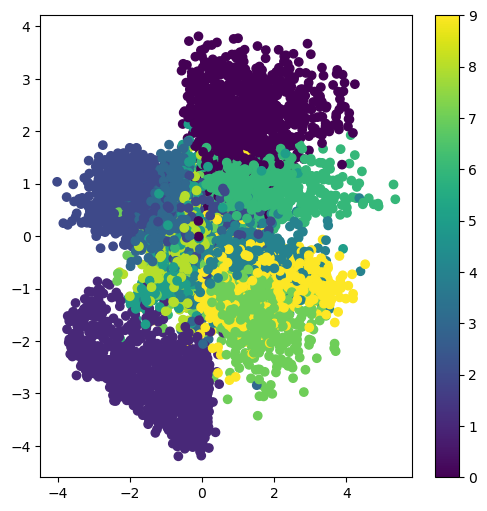

In [7]:
import matplotlib.pyplot as plt

x_test_encoded = np.asarray(encoder.predict(x_test, batch_size=128))

plt.figure(figsize=(6, 6))
plt.scatter(x_test_encoded[0, :, 0], x_test_encoded[0, :, 1], c=y_test)
plt.colorbar()
plt.show()

Each of these colored clusters is a type of digit. Close clusters are digits that are structurally similar (i.e. digits that share information in the latent space).



Because the VAE is a generative model, we can also use it to generate new digits! Here we will scan the latent plane, sampling latent points at regular intervals, and generating the corresponding digit for each of these points. This gives us a visualization of the latent manifold that "generates" the MNIST digits.



In [8]:
# Create a 2D manifold of the digits
n = 15  # figure with 15x15 digits
digit_size = 28
image = np.zeros((digit_size * n, digit_size * n))

# We will sample n points within [-5, 5] standard deviations
grid_x = np.linspace(-5, 5, n)
grid_y = np.linspace(-5, 5, n)

for i, yi in enumerate(grid_x):
    for j, xi in enumerate(grid_y):
        z_sample = np.array([[xi, yi]])
        x_decoded = decoder.predict(z_sample)
        digit = x_decoded[0].reshape(digit_size, digit_size)
        image[i * digit_size: (i + 1) * digit_size,
               j * digit_size: (j + 1) * digit_size] = digit

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1

Now, let's visualize the latent space of the VAE model:

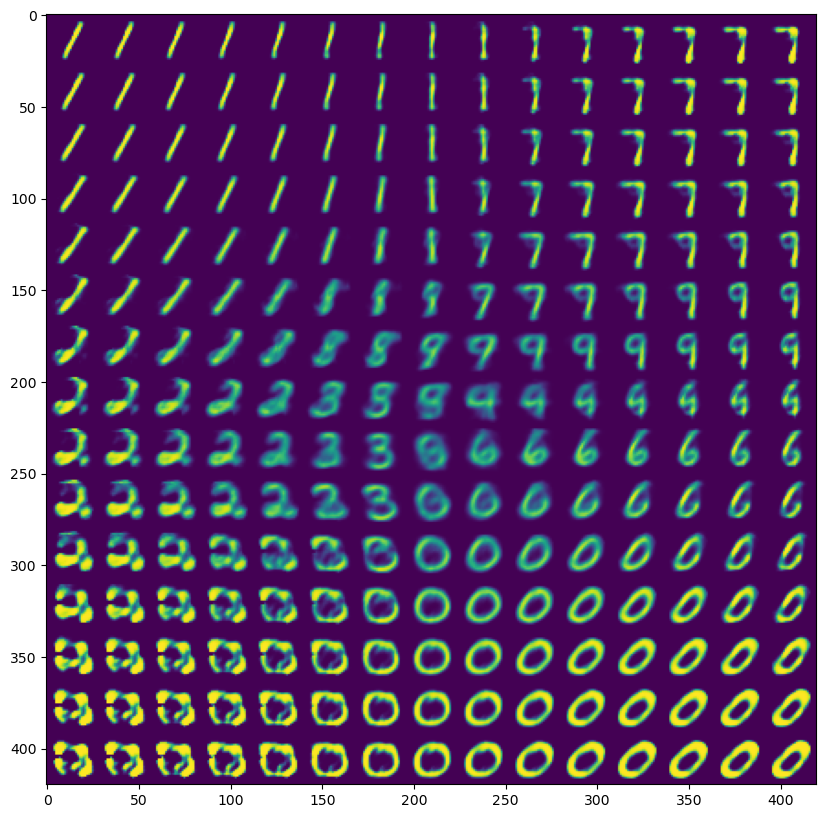

In [9]:
plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.show()

### Conditional VAEs

The VAE above generates digits, but we can't ask it for *a specific* digit — we only sample from the marginal distribution. Often we want **controlled** generation: "give me a 7", or "give me a temperature field for the year 2070 under a high-emissions scenario".


The fix is small. We condition both the encoder and the decoder on the desired attribute $c$ (here, a class label):

- **Encoder:** $q(z \mid x, c)$ — concatenate $c$ to the input
- **Decoder:** $p(x \mid z, c)$ — concatenate $c$ to the latent

The ELBO becomes $\mathbb{E}_q[\log p(x|z,c)] - \mathrm{KL}\!\bigl(q(z|x,c)\,\|\,p(z)\bigr)$. Everything else is unchanged.


### CVAE on MNIST: encoder and decoder


In [10]:
# Conditional VAE on MNIST — same architecture as the VAE above, plus a label input.
num_classes = 10

# Encoder: (image, label) -> (z_mean, z_log_sigma, z)
img_in   = keras.Input(shape=(original_dim,), name='image')
label_in = keras.Input(shape=(num_classes,),  name='label')
h_enc = layers.Dense(256, activation='relu')(
    layers.Concatenate()([img_in, label_in])
)
z_mean_c      = layers.Dense(latent_dim)(h_enc)
z_log_sigma_c = layers.Dense(latent_dim)(h_enc)
z_c = Sampling()([z_mean_c, z_log_sigma_c])
cvae_encoder = keras.Model([img_in, label_in],
                           [z_mean_c, z_log_sigma_c, z_c],
                           name='cvae_encoder')

# Decoder: (z, label) -> image
z_in      = keras.Input(shape=(latent_dim,),  name='z')
label_in2 = keras.Input(shape=(num_classes,), name='label_dec')
h_dec = layers.Dense(256, activation='relu')(
    layers.Concatenate()([z_in, label_in2])
)
img_out = layers.Dense(original_dim, activation='sigmoid')(h_dec)
cvae_decoder = keras.Model([z_in, label_in2], img_out, name='cvae_decoder')


### Training the CVAE


In [11]:
class CustomCVAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder, self.decoder = encoder, decoder

    def call(self, inputs, training=False):
        image, label = inputs
        z_mean, z_log_sigma, z = self.encoder([image, label])
        reconstruction = self.decoder([z, label])
        kl = -0.5 * ops.mean(
            ops.sum(1 + z_log_sigma - ops.square(z_mean) - ops.exp(z_log_sigma), axis=-1)
        )
        self.add_loss(kl)
        return reconstruction


# Prepare one-hot labels for the MNIST classes.
y_train_oh = keras.utils.to_categorical(y_train, num_classes).astype('float32')
y_test_oh  = keras.utils.to_categorical(y_test,  num_classes).astype('float32')

cvae = CustomCVAE(cvae_encoder, cvae_decoder)
# Same per-sample-sum reconstruction loss as the VAE — without this rescaling,
# the KL term dominates and the model ignores both x and the label.
cvae.compile(optimizer='adam', loss=vae_reconstruction_loss)
cvae.fit([x_train, y_train_oh], x_train, epochs=20, batch_size=256)


Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 216.9450
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 155.5701
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 146.1273
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 142.7646
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 140.9456
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 139.6689
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 138.7003
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 137.9379
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 137.2755
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 136.7248
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 136.2263
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 135.8011
Epoch 13/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 135.3937
Epoch 14/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 135.0816
Epoch 15/20
235/235 ━━━━━━━━━

### Conditional generation

With the trained CVAE we can now **choose** the digit class and let $z$ vary. Each row below holds the label fixed and varies $z$, giving different stylistic instances of the same digit — the controllability we wanted.


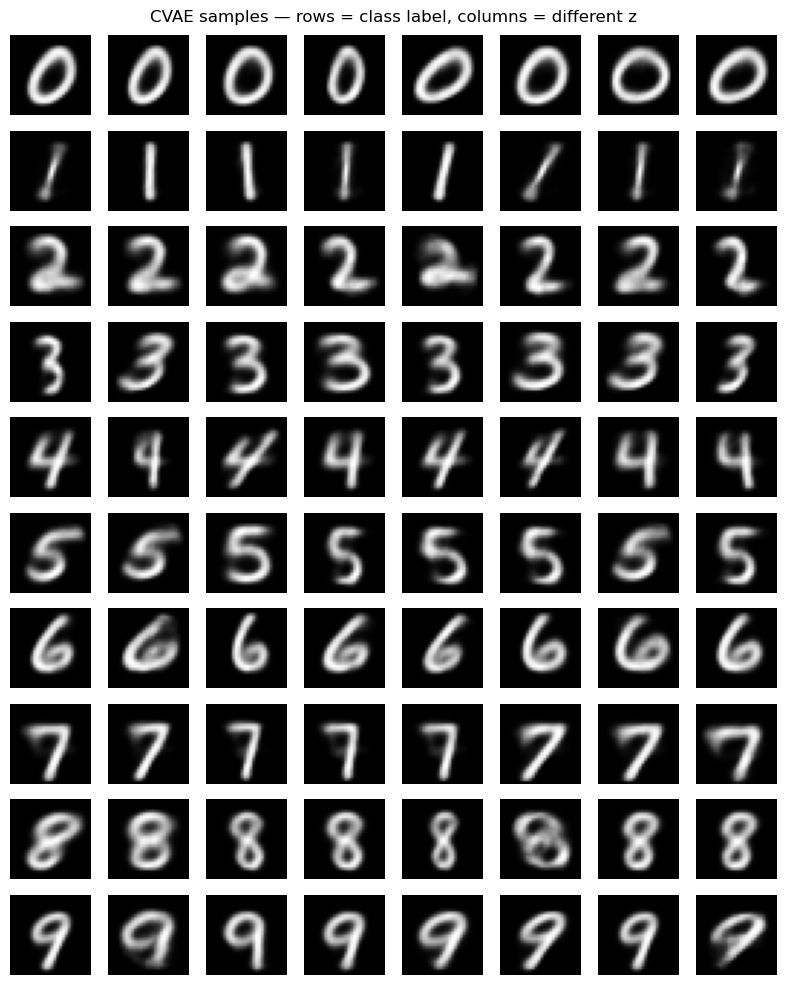

In [12]:
# For each class, sample a few z's from the prior and decode under that class label.
n_classes_to_show   = 10
n_samples_per_class = 8
rng = np.random.default_rng(0)

fig, axes = plt.subplots(n_classes_to_show, n_samples_per_class,
                        figsize=(n_samples_per_class, n_classes_to_show))
for c in range(n_classes_to_show):
    label = keras.utils.to_categorical([c] * n_samples_per_class, num_classes).astype('float32')
    z = rng.standard_normal((n_samples_per_class, latent_dim)).astype('float32')
    imgs = cvae_decoder.predict([z, label], verbose=0).reshape(-1, 28, 28)
    for j in range(n_samples_per_class):
        axes[c, j].imshow(imgs[j], cmap='gray')
        axes[c, j].axis('off')
    axes[c, 0].set_ylabel(str(c), rotation=0, labelpad=15, fontsize=12)
plt.suptitle('CVAE samples — rows = class label, columns = different z')
plt.tight_layout()
plt.show()


The same conditioning trick — concatenate (or embed) $c$ wherever the network can see it — generalizes directly to **conditional diffusion**, which we'll see next.


### A historical note: Generative Adversarial Networks (GANs)

Before diffusion, **GANs** dominated image generation (2014–2020). The idea was elegant: train a *generator* $G$ and a *discriminator* $D$ adversarially, so $G$ learns to produce samples indistinguishable from real data. Variants like CycleGAN (image-to-image translation) and StyleGAN (high-quality faces) were genuinely impressive.

In practice, GANs were notoriously **unstable to train** (mode collapse, vanishing discriminators, sensitive hyperparameters) and provided **no tractable likelihood**. Since ~2021, diffusion models have largely displaced them — including in nearly every geoscience use case. We mention GANs so you recognize the name in older papers, but won't implement one.

<center><img src="_images/stylegan-teaser.png" alt="stylegan" width="500"/></center>


## The growth of generative models

### Diffusion Models

Another type of generative model that has gained popularity in recent years is diffusion models. Diffusion models are based on the idea of modeling the data distribution as a diffusion process, where the data is gradually transformed from a simple distribution to the target distribution.



The key idea behind diffusion models is to learn a sequence of transformations that map the data from a simple distribution to the target distribution. The transformations are learned using a denoising autoencoder, where the input is a noisy sample and the output is a clean sample.

<center><img src="_images/diffusion_example.gif" alt="diffusion" width="300"/></center>

### Diffusion Models

They're similar to VAEs in that they learn a probabilistic representation of the data, but they're different in that they model the data distribution as a diffusion process rather than a latent space. This means the latent space is less interpretable, but the model can generate high-quality samples by sampling from the learned diffusion process.


### How do Diffusion Models Work?

Diffusion models generate data by gradually transforming random noise into a structured sample, such as an image, through a series of small steps. The process involves two main phases:

1. **Forward Process (Adding Noise):**
    - Starting with a real data sample (like an image), the model adds a small amount of random noise at each step.
    - After many steps, the data becomes nearly pure noise.
    - This process is mathematically defined so that each step (and their product) is predictable and reversible.


![Forward process](_images/forward_diffusion.png)



2. **Reverse Process (Denoising):**
    - The model learns how to reverse the noising process, step by step, turning noise back into a realistic sample.
    - At each step, the model predicts and removes a bit of noise, slowly recovering the structure of the original data.
    - By starting from pure noise and applying the learned denoising steps, the model can generate new, realistic samples.


![Reverse process](_images/reverse_diffusion.png)

### How do Diffusion Models Work?

This approach is powerful because it allows the model to learn complex data distributions in a stable and controllable way. The key idea is that by breaking down the generation process into many small, simple steps, the model can learn to create high-quality, diverse outputs.

The training of diffusion models involves optimizing the model to predict the noise added at each step, effectively learning how to denoise the data. This is done by minimizing a loss function that measures the difference between the predicted noise and the actual noise added during the forward process.


### Diffusion Models in Practice

The loss function used in diffusion models is typically a variant of the mean squared error (MSE) loss, which measures the difference between the predicted noise and the actual noise added during the forward process. The model is trained to minimize this loss, effectively learning how to denoise the data:

$$
\mathcal{L} = \mathbb{E}_{x, t} \left[ \| \epsilon - \epsilon_\theta(x_t, t) \|^2 \right]
$$

Where $x_t$ is the noisy sample at time step $t$, $\epsilon$ is the actual noise added, and $\epsilon_\theta(x_t, t)$ is the predicted noise by the model.



A key component of diffusion models is the noise schedule, which defines how much noise is added at each step of the forward process. The noise schedule can be linear, cosine, or learned, and it plays a crucial role in the quality of the generated samples.

A useful unifying view: predicting the noise $\epsilon$ is (up to scaling) equivalent to estimating the **score** of the noisy data distribution, $\nabla_{x_t} \log p_t(x_t)$. This is why "denoising diffusion" and "score-based generative modeling" are the same family viewed from two angles.

### Diffusion Models in Practice

There are several popular diffusion models, including:
- **DDPM (Denoising Diffusion Probabilistic Models)**: A foundational diffusion model that introduced the concept of diffusion-based generation.
- **Score-Based Generative Models**: These models use score matching to learn the data distribution and generate samples by sampling from the learned score function.
- **Latent Diffusion Models (LDMs)**: These models operate in a lower-dimensional latent space, making them more efficient and capable of generating high-resolution samples.


### Visualizing the forward process

Before any training, the forward (noising) process is deterministic given the noise schedule: $x_t = \sqrt{\bar\alpha_t}\, x_0 + \sqrt{1 - \bar\alpha_t}\, \epsilon$. Let's apply it to a real MNIST digit and watch the trajectory from data to pure noise.


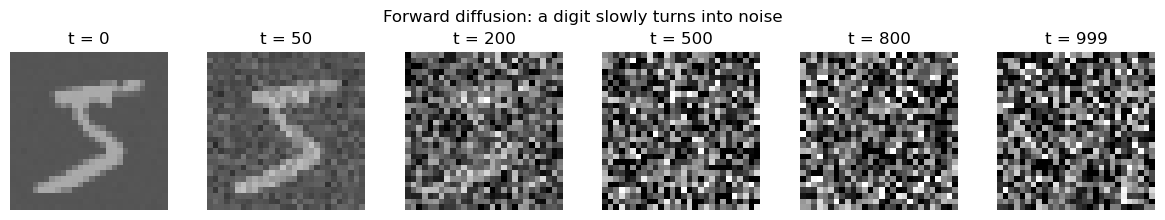

In [14]:
# Forward (noising) process on a single MNIST digit.
T = 1000
betas = np.linspace(1e-4, 0.02, T)         # linear noise schedule
alphas = 1.0 - betas
alpha_bars = np.cumprod(alphas)

x0 = x_train[0].reshape(28, 28)            # one digit
times_to_show = [0, 50, 200, 500, 800, 999]
rng = np.random.default_rng(0)

fig, axes = plt.subplots(1, len(times_to_show), figsize=(2 * len(times_to_show), 2.2))
for ax, t in zip(axes, times_to_show):
    eps = rng.standard_normal(x0.shape)
    xt = np.sqrt(alpha_bars[t]) * x0 + np.sqrt(1 - alpha_bars[t]) * eps
    ax.imshow(xt, cmap='gray', vmin=-1, vmax=2)
    ax.set_title(f't = {t}')
    ax.axis('off')
plt.suptitle('Forward diffusion: a digit slowly turns into noise')
plt.tight_layout()
plt.show()


At $t=0$ we have the clean digit; at $t=T$ we have something indistinguishable from $\mathcal{N}(0, I)$. The model's job is to **learn the inverse** of this trajectory.


### Conditional diffusion

The same conditioning trick from CVAEs works here. We feed the conditioning $c$ (label, low-resolution field, text prompt, ...) to the noise predictor:

$$\epsilon_\theta(x_t, t, c)$$

In practice $c$ is embedded into a vector and *added* (or cross-attended) inside the U-Net alongside the timestep embedding. The training loss is identical to before, just with the extra argument: $\|\epsilon - \epsilon_\theta(x_t, t, c)\|^2$.

This is how GenCast generates ensemble forecasts conditioned on a deterministic input, and how CorrDiff downscales coarse precipitation fields conditioned on the low-resolution input.


### Conditional training: pseudocode

Full training of an image-quality diffusion model is too big for my laptop, but the training loop is short:

```python
# Pseudocode — minimal conditional DDPM training and sampling.

# --- Training ---
for x0, c in dataloader:                       # x0: clean data, c: condition
    t   = randint(0, T)                        # uniform timestep
    eps = randn_like(x0)                       # epsilon ~ N(0, I)
    xt  = sqrt(alpha_bar[t]) * x0 + sqrt(1 - alpha_bar[t]) * eps
    eps_pred = noise_predictor(xt, t, c)       # e.g. a U-Net with c-embedding
    loss = mse(eps_pred, eps)
    loss.backward(); optimizer.step()

# --- Sampling ---
# Start at x_T ~ N(0, I), iteratively denoise from t=T down to 0,
# passing c at every step.  Optionally use classifier-free guidance to
# trade sample diversity for adherence to c.
```

### Climate Diffusion Models

I'm also excited about using diffusion models for sampling weather states from climate models:

<center><img src="_images/climate_diffusion.png" alt="diffusion" width="900"/></center>

### Looking ahead: a close cousin

A very recent variant called **flow matching** has largely displaced diffusion in production image-generation systems (Stable Diffusion 3, FLUX, Imagen 3, Movie Gen) over the last ~18 months. It learns a similar vector field along *straight-line* paths from noise to data, which makes sampling much faster.

We'll meet it again in the next lecture, where it turns out to be what's actually running inside modern multimodal models like DALL-E.


### Comparison and outlook

| Family | Sample quality | Training stability | Likelihood | Controllability | Geoscience adoption |
|---|---|---|---|---|---|
| **VAE** | Modest, often blurry | Easy | Lower bound (ELBO) | Good via conditioning | Some — downscaling priors, ENSO emulators |
| **GAN** *(historical)* | High when stable | Notoriously hard | None | Moderate | Mostly displaced |
| **Diffusion** | State of the art | Easy and stable | Approximate | Excellent (e.g. classifier-free guidance) | GenCast, CorrDiff, SEEDS |


In geoscience the bet right now is on **conditional diffusion** — it pairs training stability with explicit control over the conditioning input, which is exactly what downscaling, ensemble generation, and infilling all need.



## Conclusion

We've covered a lot of ground in this lecture:

- **Variational autoencoders** as a probabilistic way to encode and generate
- **Conditional VAEs** as a simple recipe for controlled generation
- **Diffusion models** as the current workhorse for high-quality samples
- A brief historical note on **GANs**


Generative models are a powerful class of machine learning models that learn the underlying distribution of the data and generate new samples from the learned distribution. They have been used in a wide range of applications and have the potential to revolutionize the way we generate new data samples.



Generative models are no longer a niche topic in geoscience. Conditional diffusion is now used for ensemble weather forecasting (GenCast), convection-permitting downscaling (CorrDiff), data infilling, and anomaly detection — and the pace of new applications is fast. Expect this to be one of the most active areas in environmental ML over the next few years.
